ASD Prevalence: 0.02706

ROC AUC: 0.655418345354596
PR AUC: 0.064857138081557

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.66      0.79     19459
           1       0.04      0.57      0.08       541

    accuracy                           0.66     20000
   macro avg       0.51      0.62      0.44     20000
weighted avg       0.96      0.66      0.77     20000



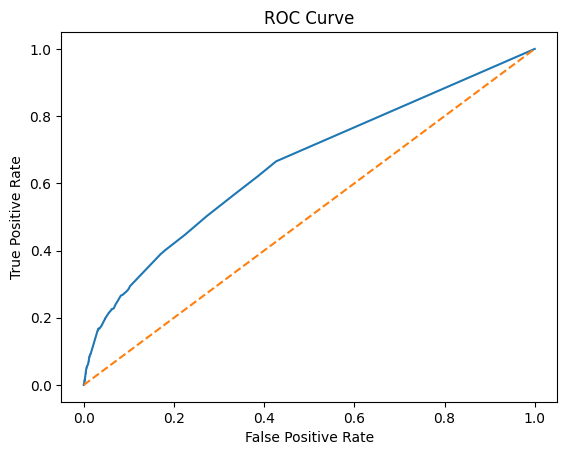

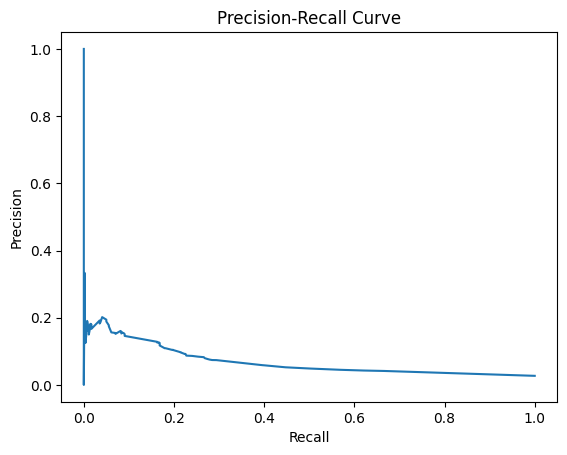

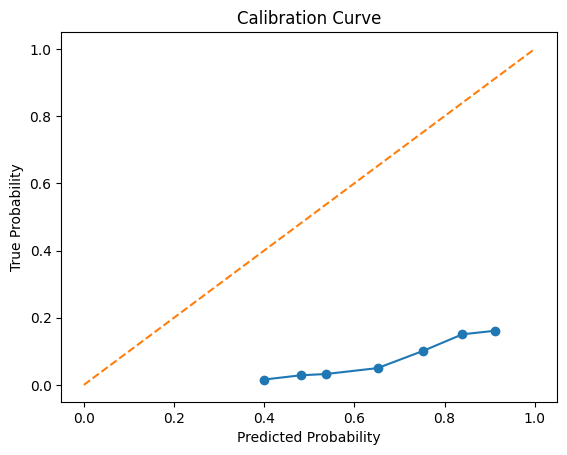


Feature Importance:
             Feature  Coefficient
6     family_history     1.516184
4            preterm     0.715759
2                gdm     0.511729
0  advanced_maternal     0.469655
3          infection     0.421983
5             low_bw     0.378168
1  advanced_paternal     0.276711


In [7]:
# ============================================
# PHASE 1: Prenatal Autism Risk Prediction
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    classification_report,
    roc_curve,
    precision_recall_curve
)
from sklearn.calibration import calibration_curve


# ============================================
# STEP 1: Generate Synthetic Dataset
# ============================================

np.random.seed(42)

N = 100000  # number of pregnancies

# Continuous variables
maternal_age = np.random.normal(28, 5, N)
paternal_age = np.random.normal(31, 6, N)

# Binary risk factors (realistic prevalence)
gdm = np.random.binomial(1, 0.08, N)
infection = np.random.binomial(1, 0.10, N)
preterm = np.random.binomial(1, 0.11, N)
low_bw = np.random.binomial(1, 0.08, N)
family_history = np.random.binomial(1, 0.03, N)

# Age thresholds
advanced_maternal = (maternal_age > 35).astype(int)
advanced_paternal = (paternal_age > 40).astype(int)

# Log-odds coefficients (from epidemiological OR values)
beta_0 = -4.0  # baseline ~2% prevalence

beta = {
    "maternal": 0.4,
    "paternal": 0.45,
    "gdm": 0.5,
    "infection": 0.4,
    "preterm": 0.6,
    "low_bw": 0.4,
    "family": 1.6
}

# Logistic function
logit = (
    beta_0
    + beta["maternal"] * advanced_maternal
    + beta["paternal"] * advanced_paternal
    + beta["gdm"] * gdm
    + beta["infection"] * infection
    + beta["preterm"] * preterm
    + beta["low_bw"] * low_bw
    + beta["family"] * family_history
)

prob = 1 / (1 + np.exp(-logit))

asd = np.random.binomial(1, prob)

df = pd.DataFrame({
    "advanced_maternal": advanced_maternal,
    "advanced_paternal": advanced_paternal,
    "gdm": gdm,
    "infection": infection,
    "preterm": preterm,
    "low_bw": low_bw,
    "family_history": family_history,
    "ASD": asd
})

print("ASD Prevalence:", df["ASD"].mean())


# ============================================
# STEP 2: Train-Test Split
# ============================================

X = df.drop("ASD", axis=1)
y = df["ASD"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# ============================================
# STEP 3: Train Logistic Regression
# ============================================

model = LogisticRegression(class_weight="balanced", max_iter=1000)
model.fit(X_train, y_train)

y_pred_prob = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)


# ============================================
# STEP 4: Evaluation
# ============================================

roc_auc = roc_auc_score(y_test, y_pred_prob)
pr_auc = average_precision_score(y_test, y_pred_prob)

print("\nROC AUC:", roc_auc)
print("PR AUC:", pr_auc)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


# ============================================
# STEP 5: ROC Curve
# ============================================

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()


# ============================================
# STEP 6: Precision-Recall Curve
# ============================================

precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()


# ============================================
# STEP 7: Calibration Curve
# ============================================

prob_true, prob_pred = calibration_curve(y_test, y_pred_prob, n_bins=10)

plt.figure()
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("Predicted Probability")
plt.ylabel("True Probability")
plt.title("Calibration Curve")
plt.show()


# ============================================
# STEP 8: Feature Importance
# ============================================

importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

print("\nFeature Importance:")
print(importance)

ASD Prevalence: 0.02706


c:\Users\WIN11\Desktop\JonathanGomes\BE\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:38:49] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



ROC AUC: 0.6525373649264357
PR AUC: 0.06231473141968857

Classification Report (Threshold = 0.15 )
              precision    recall  f1-score   support

           0       0.92      0.00      0.00     19459
           1       0.03      1.00      0.05       541

    accuracy                           0.03     20000
   macro avg       0.47      0.50      0.03     20000
weighted avg       0.89      0.03      0.00     20000



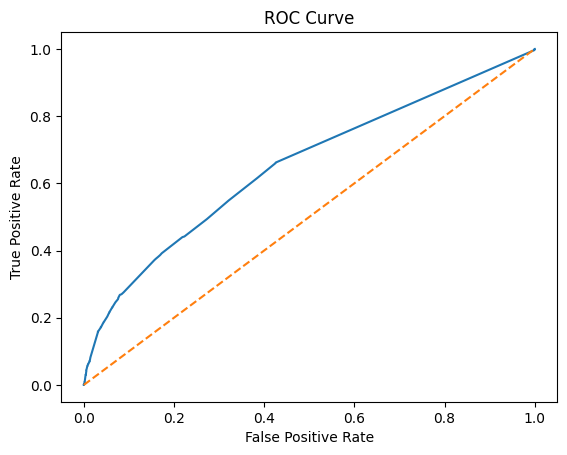

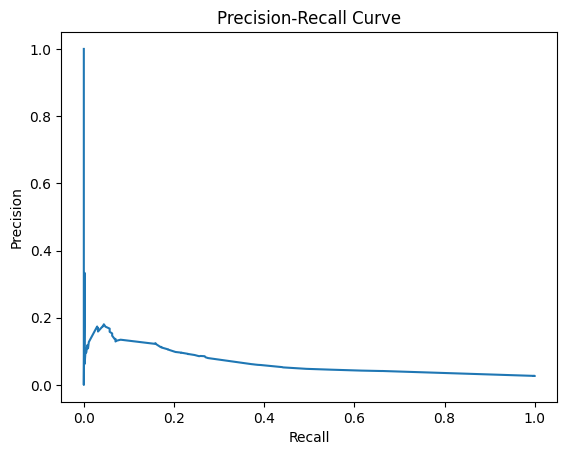

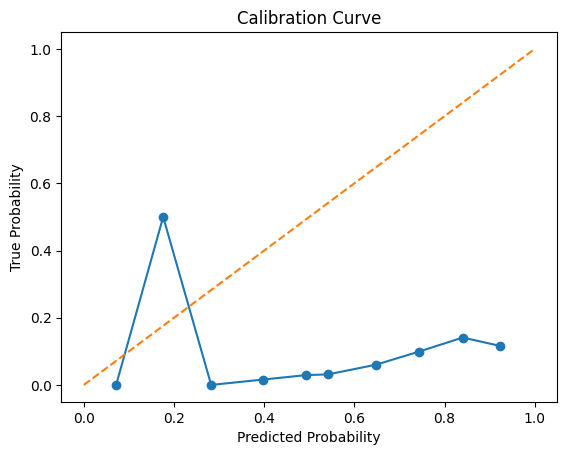


Feature Importance:
             Feature  Importance
6     family_history    0.437262
4            preterm    0.206578
2                gdm    0.086604
3          infection    0.081264
0  advanced_maternal    0.076740
5             low_bw    0.064557
1  advanced_paternal    0.046995


In [8]:
# =====================================================
# PHASE 1: Prenatal Autism Risk Prediction (Improved)
# =====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    classification_report,
    roc_curve,
    precision_recall_curve
)
from sklearn.calibration import calibration_curve
from xgboost import XGBClassifier


# =====================================================
# STEP 1: Generate Synthetic Dataset
# =====================================================

np.random.seed(42)

N = 100000  # Larger dataset for stronger modeling

maternal_age = np.random.normal(28, 5, N)
paternal_age = np.random.normal(31, 6, N)

gdm = np.random.binomial(1, 0.08, N)
infection = np.random.binomial(1, 0.10, N)
preterm = np.random.binomial(1, 0.11, N)
low_bw = np.random.binomial(1, 0.08, N)
family_history = np.random.binomial(1, 0.03, N)

advanced_maternal = (maternal_age > 35).astype(int)
advanced_paternal = (paternal_age > 40).astype(int)

# Log-odds (literature based)
beta_0 = -4.0
beta = {
    "maternal": 0.4,
    "paternal": 0.45,
    "gdm": 0.5,
    "infection": 0.4,
    "preterm": 0.6,
    "low_bw": 0.4,
    "family": 1.6
}

logit = (
    beta_0
    + beta["maternal"] * advanced_maternal
    + beta["paternal"] * advanced_paternal
    + beta["gdm"] * gdm
    + beta["infection"] * infection
    + beta["preterm"] * preterm
    + beta["low_bw"] * low_bw
    + beta["family"] * family_history
)

prob = 1 / (1 + np.exp(-logit))
asd = np.random.binomial(1, prob)

df = pd.DataFrame({
    "advanced_maternal": advanced_maternal,
    "advanced_paternal": advanced_paternal,
    "gdm": gdm,
    "infection": infection,
    "preterm": preterm,
    "low_bw": low_bw,
    "family_history": family_history,
    "ASD": asd
})

print("ASD Prevalence:", df["ASD"].mean())


# =====================================================
# STEP 2: Train-Test Split
# =====================================================

X = df.drop("ASD", axis=1)
y = df["ASD"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# =====================================================
# STEP 3: Train XGBoost Model
# =====================================================

# Handle imbalance using scale_pos_weight
scale_pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)

model = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

y_pred_prob = model.predict_proba(X_test)[:, 1]


# =====================================================
# STEP 4: Evaluation
# =====================================================

roc_auc = roc_auc_score(y_test, y_pred_prob)
pr_auc = average_precision_score(y_test, y_pred_prob)

print("\nROC AUC:", roc_auc)
print("PR AUC:", pr_auc)


# =====================================================
# STEP 5: Threshold Tuning
# =====================================================

threshold = 0.15  # Adjust this value (0.05–0.3)
y_pred_custom = (y_pred_prob > threshold).astype(int)

print("\nClassification Report (Threshold =", threshold, ")")
print(classification_report(y_test, y_pred_custom))


# =====================================================
# STEP 6: ROC Curve
# =====================================================

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()


# =====================================================
# STEP 7: Precision-Recall Curve
# =====================================================

precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()


# =====================================================
# STEP 8: Calibration Curve
# =====================================================

prob_true, prob_pred = calibration_curve(y_test, y_pred_prob, n_bins=10)

plt.figure()
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("Predicted Probability")
plt.ylabel("True Probability")
plt.title("Calibration Curve")
plt.show()


# =====================================================
# STEP 9: Feature Importance
# =====================================================

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance:")
print(importance)

ASD Prevalence: 0.02834

ROC AUC: 0.6389049754544874
PR AUC: 0.07195248940655358

Best Threshold: 0.5
Best F1 Score: 0.09712159780693166

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.78      0.87     19433
           1       0.05      0.44      0.10       567

    accuracy                           0.77     20000
   macro avg       0.52      0.61      0.48     20000
weighted avg       0.95      0.77      0.85     20000



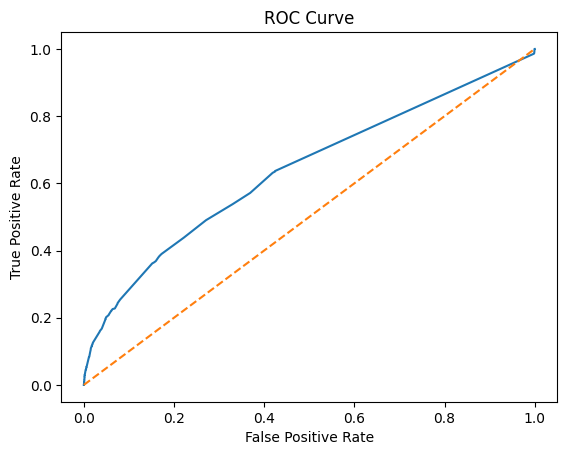

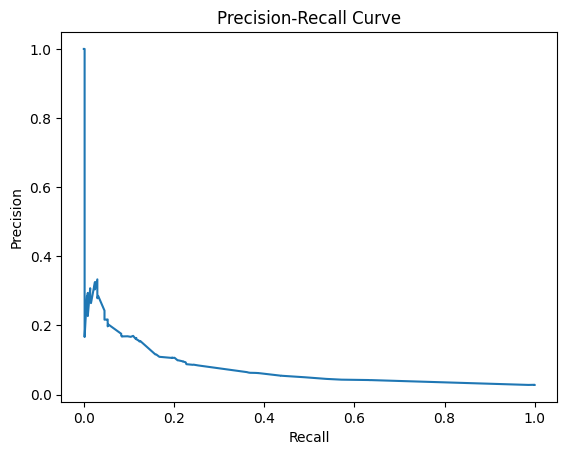

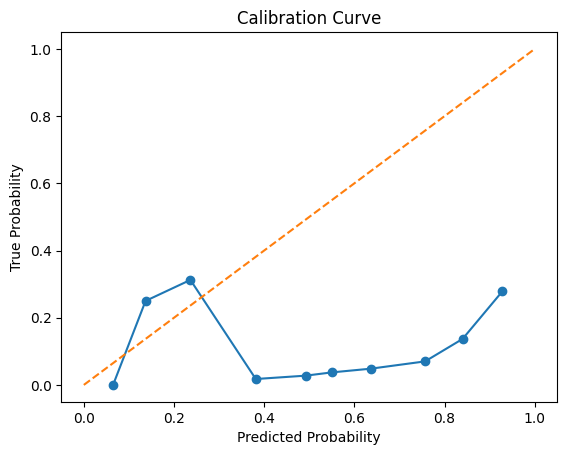


Feature Importance:
             Feature  Importance
6     family_history    0.390135
4            preterm    0.247334
2                gdm    0.140939
3          infection    0.072825
0  advanced_maternal    0.068264
1  advanced_paternal    0.043358
5             low_bw    0.037145


In [9]:
# ==========================================================
# PHASE 1: Prenatal Autism Risk Prediction (Advanced)
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    classification_report,
    roc_curve,
    precision_recall_curve,
    f1_score
)
from sklearn.calibration import calibration_curve
from xgboost import XGBClassifier


# ==========================================================
# STEP 1: Generate Realistic Synthetic Dataset
# ==========================================================

np.random.seed(42)

N = 100000

# Continuous variables
maternal_age = np.random.normal(28, 5, N)
paternal_age = np.random.normal(31, 6, N)

# Binary features (realistic prevalence)
gdm = np.random.binomial(1, 0.08, N)
infection = np.random.binomial(1, 0.10, N)
preterm = np.random.binomial(1, 0.11, N)
low_bw = np.random.binomial(1, 0.08, N)
family_history = np.random.binomial(1, 0.03, N)

advanced_maternal = (maternal_age > 35).astype(int)
advanced_paternal = (paternal_age > 40).astype(int)

# Log-odds coefficients (from epidemiological OR)
beta_0 = -4.0
beta = {
    "maternal": 0.4,
    "paternal": 0.45,
    "gdm": 0.5,
    "infection": 0.4,
    "preterm": 0.6,
    "low_bw": 0.4,
    "family": 1.6
}

# Add interaction effects (more realistic complexity)
logit = (
    beta_0
    + beta["maternal"] * advanced_maternal
    + beta["paternal"] * advanced_paternal
    + beta["gdm"] * gdm
    + beta["infection"] * infection
    + beta["preterm"] * preterm
    + beta["low_bw"] * low_bw
    + beta["family"] * family_history
    + 0.8 * (gdm * preterm)
    + 0.6 * (infection * preterm)
    + 0.5 * (advanced_maternal * gdm)
)

prob = 1 / (1 + np.exp(-logit))
asd = np.random.binomial(1, prob)

df = pd.DataFrame({
    "advanced_maternal": advanced_maternal,
    "advanced_paternal": advanced_paternal,
    "gdm": gdm,
    "infection": infection,
    "preterm": preterm,
    "low_bw": low_bw,
    "family_history": family_history,
    "ASD": asd
})

print("ASD Prevalence:", df["ASD"].mean())


# ==========================================================
# STEP 2: Train-Test Split
# ==========================================================

X = df.drop("ASD", axis=1)
y = df["ASD"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# ==========================================================
# STEP 3: Train XGBoost Model
# ==========================================================

scale_pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)

model = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

y_pred_prob = model.predict_proba(X_test)[:, 1]


# ==========================================================
# STEP 4: Evaluation Metrics
# ==========================================================

roc_auc = roc_auc_score(y_test, y_pred_prob)
pr_auc = average_precision_score(y_test, y_pred_prob)

print("\nROC AUC:", roc_auc)
print("PR AUC:", pr_auc)


# ==========================================================
# STEP 5: Automatic Threshold Optimization (F1)
# ==========================================================

thresholds = np.linspace(0.01, 0.5, 100)
best_f1 = 0
best_threshold = 0

for t in thresholds:
    preds = (y_pred_prob > t).astype(int)
    score = f1_score(y_test, preds)
    if score > best_f1:
        best_f1 = score
        best_threshold = t

print("\nBest Threshold:", best_threshold)
print("Best F1 Score:", best_f1)

y_pred_final = (y_pred_prob > best_threshold).astype(int)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_final))


# ==========================================================
# STEP 6: ROC Curve
# ==========================================================

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()


# ==========================================================
# STEP 7: Precision-Recall Curve
# ==========================================================

precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()


# ==========================================================
# STEP 8: Calibration Curve
# ==========================================================

prob_true, prob_pred = calibration_curve(y_test, y_pred_prob, n_bins=10)

plt.figure()
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("Predicted Probability")
plt.ylabel("True Probability")
plt.title("Calibration Curve")
plt.show()


# ==========================================================
# STEP 9: Feature Importance
# ==========================================================

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance:")
print(importance)

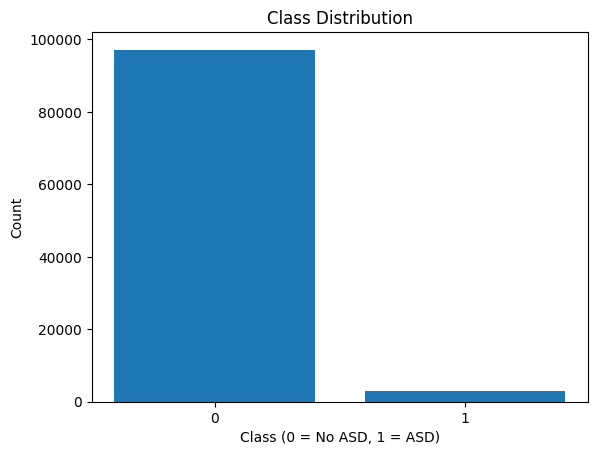

In [10]:
import matplotlib.pyplot as plt

counts = df["ASD"].value_counts()

plt.figure()
plt.bar(counts.index.astype(str), counts.values)
plt.xlabel("Class (0 = No ASD, 1 = ASD)")
plt.ylabel("Count")
plt.title("Class Distribution")
plt.show()

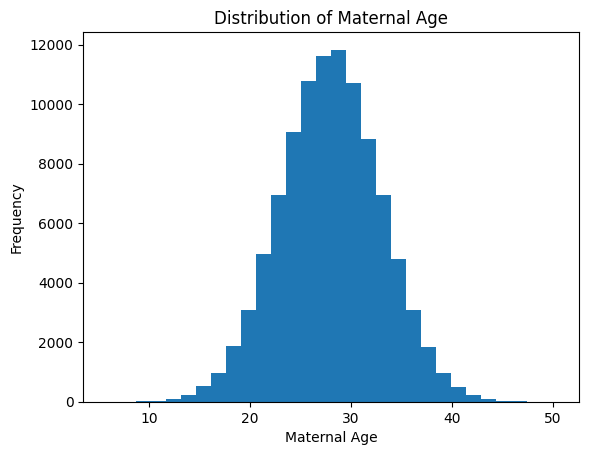

In [11]:
plt.figure()
plt.hist(maternal_age, bins=30)
plt.xlabel("Maternal Age")
plt.ylabel("Frequency")
plt.title("Distribution of Maternal Age")
plt.show()

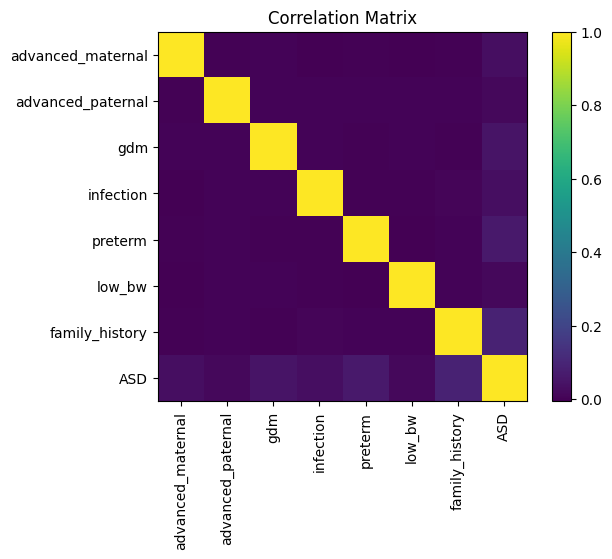

In [12]:
import numpy as np

corr = df.corr()

plt.figure()
plt.imshow(corr)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.colorbar()
plt.show()

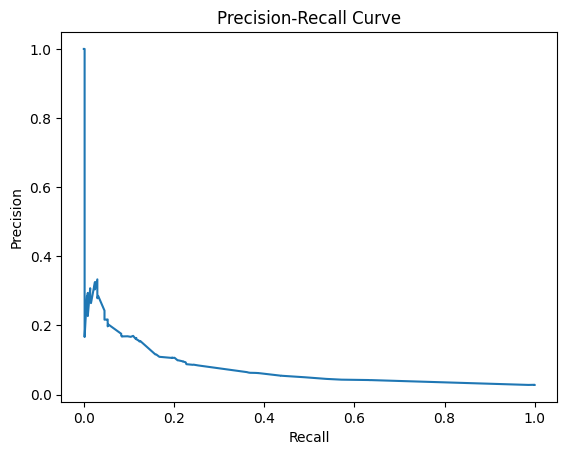

In [13]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

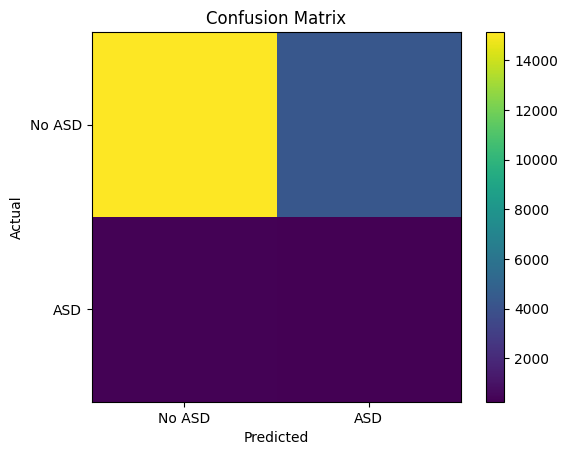

In [14]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_final)

plt.figure()
plt.imshow(cm)
plt.xticks([0,1], ["No ASD","ASD"])
plt.yticks([0,1], ["No ASD","ASD"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.colorbar()
plt.show()

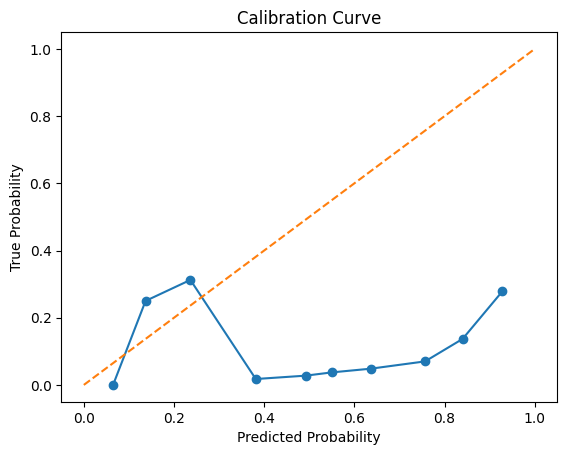

In [15]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test, y_pred_prob, n_bins=10)

plt.figure()
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1], linestyle='--')
plt.xlabel("Predicted Probability")
plt.ylabel("True Probability")
plt.title("Calibration Curve")
plt.show()

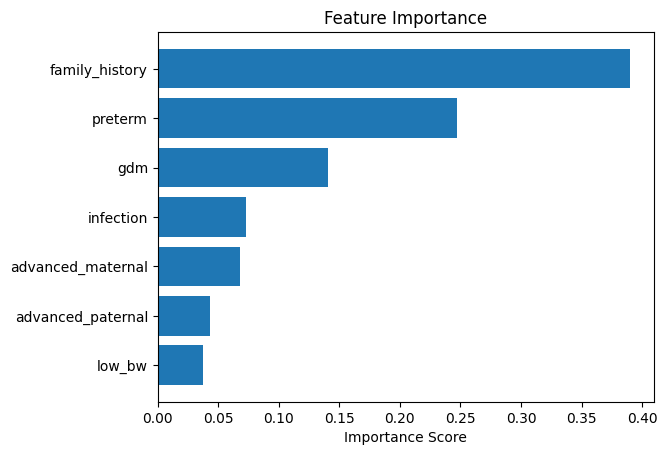

In [16]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=True)

plt.figure()
plt.barh(importance["Feature"], importance["Importance"])
plt.xlabel("Importance Score")
plt.title("Feature Importance")
plt.show()

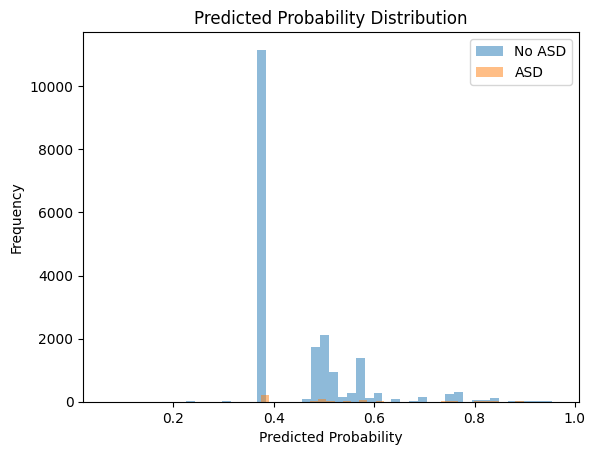

In [17]:
plt.figure()
plt.hist(y_pred_prob[y_test == 0], bins=50, alpha=0.5, label="No ASD")
plt.hist(y_pred_prob[y_test == 1], bins=50, alpha=0.5, label="ASD")
plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")
plt.title("Predicted Probability Distribution")
plt.legend()
plt.show()

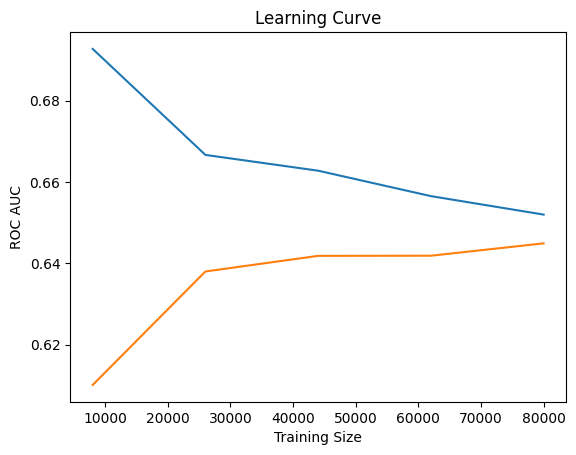

In [18]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    model, X, y, cv=5, scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure()
plt.plot(train_sizes, train_mean)
plt.plot(train_sizes, test_mean)
plt.xlabel("Training Size")
plt.ylabel("ROC AUC")
plt.title("Learning Curve")
plt.show()